# Medical Insurance Cost Prediction Using Linear Regression

##This project uses the Insurance Dataset to predict medical insurance charges using Linear Regression. The project demonstrates  model training, evaluation, and interpretation of results.


##Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

##Load Cleaned Dataset

In [4]:
df=pd.read_csv("cleaned_insurance.csv")

In [5]:

print("The cleaned dataset was loaded successfully for machine learning modeling.")
df.head()

The cleaned dataset was loaded successfully for machine learning modeling.


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,-1.438764,1,-0.453320,-0.908614,1,0.298584,False,False,True
1,-1.509965,0,0.509621,-0.078767,0,-0.953689,False,True,False
2,-0.797954,0,0.383307,1.580926,0,-0.728675,False,True,False
3,-0.441948,0,-1.305531,-0.908614,0,0.719843,True,False,False
4,-0.513149,0,-0.292556,-0.908614,0,-0.776802,True,False,False


##Feature Selection - Select Features & Target

In [6]:
X=df.drop("charges",axis=1)
y=df["charges"]

print(X.head())
print(y.head())


        age  sex       bmi  children  smoker  region_northwest  \
0 -1.438764    1 -0.453320 -0.908614       1             False   
1 -1.509965    0  0.509621 -0.078767       0             False   
2 -0.797954    0  0.383307  1.580926       0             False   
3 -0.441948    0 -1.305531 -0.908614       0              True   
4 -0.513149    0 -0.292556 -0.908614       0              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  
0    0.298584
1   -0.953689
2   -0.728675
3    0.719843
4   -0.776802
Name: charges, dtype: float64


Independent variables were selected as features (X), while charges were selected as the target variable (y)


##Train Test Split


In [7]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

The dataset was divided into training and testing sets using an 80:20 ratio.


##Create Linear Regression Model

In [8]:
model = LinearRegression()

Creates empty ML model.

##Train the Model

In [25]:
# Creating Linear Regression model
model.fit(X_train, y_train)

LinearRegression()

The Linear Regression model was trained using the training dataset.

##Output Intercept & Coefficients

In [22]:
print("Intercept:")

print(model.intercept_)


print("\nCoefficients:")

#model.coef_
for column, coef in zip(X.columns, model.coef_):
    print(column, ":", coef)

Intercept:
-0.3587573718201971

Coefficients:
age : 0.2981416296633463
sex : 0.0015358072541953316
bmi : 0.1697482643195064
children : 0.042334435195929644
smoker : 1.9537531047709231
region_northwest : -0.030620609333382752
region_southeast : -0.054344315646396885
region_southwest : -0.06689524259600356


Positive coefficient increases charges

Negative coefficient decreases charges

smoker has largest coefficient Meaning smoking strongly increases medical charges.

Regression coefficients indicate how strongly each feature affects insurance charges.

##Make Predictions

In [23]:
y_pred = model.predict(X_test)

The trained model predicted insurance charges for the test dataset.

##Evaluation Metrics

In [24]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)


mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)


r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

MAE: 0.3453966926723373
MSE: 0.22926355667538673
R² Score: 0.7835929767120722


Average prediction error , Lower = better.

mse Punishes large mistakes more Lower = better.

R2 How much variation model explains.

The model achieved a good R² score, indicating strong predictive performance.


##Actual vs Predicted Scatter Plot

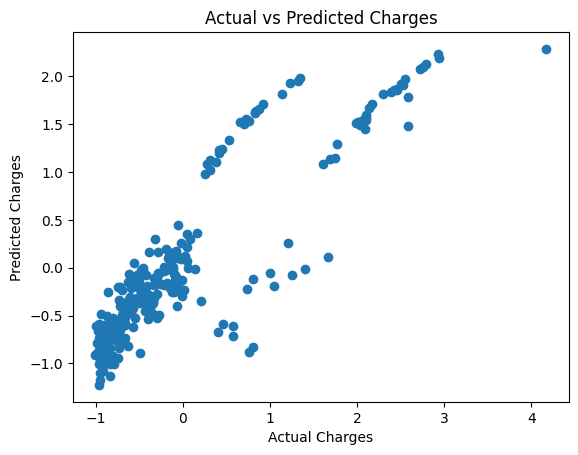

In [33]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Charges")

plt.ylabel("Predicted Charges")

plt.title("Actual vs Predicted Charges")

plt.show()


The scatter plot shows a positive relationship between actual and predicted charges, indicating good model performance.


##Residual Plot

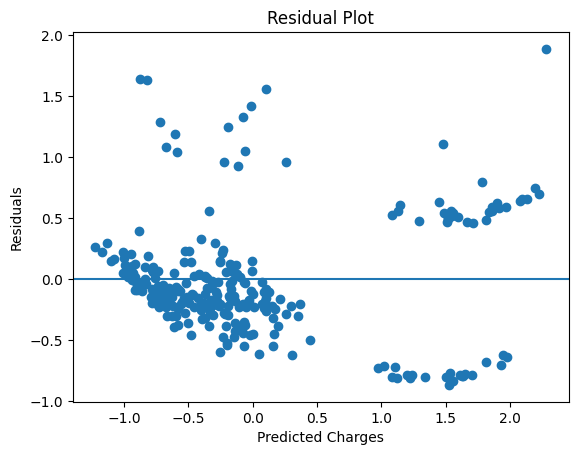

In [34]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Charges")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

The residual plot shows errors distributed around zero, indicating that the model fits the data reasonably well.

The model predicted insurance charges reasonably well. Smoking was the most important factor affecting charges, followed by BMI and age. The evaluation scores and graphs show that the model works well and gives good predictions.